***Tests***

In [1]:
import torch
import numpy as np
from scipy.optimize import minimize
from modele import *
from visualisation import *
from pytorch_optim import *
%load_ext autoreload
%autoreload 2


In [2]:
N=3
nb_colonnes_default = 50
T = 300
L = 5
P0 = torch.tensor([[0, 1 / 2, 1], [1 / 2, 0, 0], [1 / 2, 1 / 2, 0]]) 
params = {
    "N": N,  # nombre de couches
    "L": L,  # longueur du bassin
    "H": 1,  # hauteur du bassin
    "nb_colonnes_default": 50,  # discrétisation horizontale
    "D": 1e-5,  # coefficient de diffusion
    "T": T,  # temps final pour 20 tours
    "CFL": 0.95,  # facteur CFL
    "u" : [0.1]*N,
    "I_s": 1500,
    "epsilon": 4.6,
    "k_d": 2.99e-4,   # 2.99*10e-5 = 2.99e-4
    "k_r": 4.8e-4,    # 4.8*10e-5 = 4.8e-4
    "k_h": 3.64e-4,   # 3.64*10e-5 = 3.64e-4
    "tau": 6.849,
    "sigma_H": 2.9e-3,  # 2.9*10e-4 = 2.9e-3
    "theta": 3.64e-4 * 2.9e-3,  # k_h * sigma_H
    "I_star": np.sqrt(4.8e-4 / (2.99e-4 * 6.849 * (2.9e-3)**2)),
    "mu_max": 3.64e-4 * 2.9e-3 / (6.849 * 2.9e-3 + 2*np.sqrt((2.99e-4 * 6.849 * (2.9e-3)**2)/4.8e-4))
}

In [ ]:
# Un tenseur simple
x = torch.tensor([1, 2, 3])

# Aléatoire
y = torch.randn(2, 3)

# Zéros
z = torch.zeros(3, 3)

print(x, y, z)

tensor([1, 2, 3]) tensor([[-2.0857,  1.2991,  2.0050],
        [-1.2505, -0.3454,  0.2293]]) tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [ ]:
a = torch.tensor([1., 2., 3.])
b = torch.tensor([4., 5., 6.])

print(a + b)
print(a * b)
print(a.mean())


tensor([5., 7., 9.])
tensor([ 4., 10., 18.])
tensor(2.)


In [ ]:
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 3*x + 1   # fonction à dériver
y.backward()

print(x.grad)

tensor(7.)


In [ ]:
x = torch.tensor(2.0, requires_grad=True)
def f(x):
    return x**2 - x

f(x).backward()

print(x.grad)

tensor(3.)


***Optimiser une fonction simple à deux paramètres.***

In [ ]:
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(1.0, requires_grad=True)

f = (x - 5)**2 + (y - 2)**2 

optim = torch.optim.Adam([x, y], lr=0.001)

for k in range(20000):
    optim.zero_grad()
    f = (x - 5)**2 + (y - 2)**2 
    f.backward()
    optim.step()

print("x:", x.item(), "y:", y.item())

x: 5.0 y: 2.0


Maintenant, essayons d'optimiser cette fonction sur la courbe $y = x^2 - 1$.

In [ ]:
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(1.0, requires_grad=True)

optim = torch.optim.Adam([x, y], lr=0.01)
for p in range(10):
    epsilon = 10**(-p)
    for k in range(1000):
        optim.zero_grad()
        f = (x - 5)**2 + (y - 2)**2 + 1/epsilon*(x**2 - y - 1)**2 #pénalisation
        f.backward()
        optim.step()
    print(f'epsilon = {epsilon}' + ", x:", x.item(), "y:", y.item())

epsilon = 1, x: 2.094550371170044 y: 2.693570613861084
epsilon = 0.1, x: 1.9624724388122559 y: 2.7739076614379883
epsilon = 0.01, x: 1.9472311735153198 y: 2.7838704586029053
epsilon = 0.001, x: 1.9455440044403076 y: 2.7843570709228516
epsilon = 0.0001, x: 1.9440456628799438 y: 2.7792351245880127
epsilon = 1e-05, x: 1.9427201747894287 y: 2.774153470993042
epsilon = 1e-06, x: 1.9407801628112793 y: 2.7666268348693848
epsilon = 1e-07, x: 1.9390605688095093 y: 2.759956121444702
epsilon = 1e-08, x: 1.9372775554656982 y: 2.753044366836548
epsilon = 1e-09, x: 1.9372775554656982 y: 2.753044366836548


On remarque que quand la pénalité devient trop grande, le résultat s'éloigne de la solution (1.94, 2.78). Cela provient du fait que le rapport du gradient calculé et de la learning rate ***lr***  est trop important et empêche de converger vers le minimum. Nous devons adapter le choix de la learning rate à la valeur de $\epsilon$.

Et avec un autre package :

In [ ]:
def f(x):
    return (x[0] - 5)**2 + (x[1] - 2)**2 

cons = {'type' : 'eq',
        'fun' : lambda vars: vars[0]**2 - vars[1] - 1}

res = minimize(f, x0=[1.0, 1.0], constraints=cons)
print(res)


     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 9.94614854153955
           x: [ 1.946e+00  2.785e+00]
         nit: 6
         jac: [-6.109e+00  1.570e+00]
        nfev: 19
        njev: 6
 multipliers: [-1.570e+00]


Pour mon problème de recherche des matrices de mélange, plusieurs possibilités : 
- résoudre équation de KKT en calculant les gradients par torch
- utiliser un solver (SLSQP, pulp ou autres) 
dans ce cas, choisir entre un problème sous contrainte, ou un problème relaxé avec pénalisation. 
- coder une descente de gradient à la main

a priori c'est la deuxième solution qui sera la meilleure, mais il reste à pouvoir utiliser pulp sur mes algorithmes, or ils ont pour arguments des entiers (nb_colonnes par exemple) donc non différentiables. De nombreuses reformulations du code à faire.

Essayons, pour se rapprocher du cadre du problème, de minimiser sur l'ensemble des matrices stochastiques par colonnes une fonction simple de ces matrices.

In [ ]:

#fonction qui convertit une matrice N*N en vecteur 1D

def matrix_to_vector(P):
    vect = []
    P_ = list(P)
    for line in P:
        for item in line:
            vect.append(item)
    return vect

# et inversement

def vector_to_matrix(v):
    P = np.zeros((N, N))
    for k in range(len(v)):
        P[k//N, k%N] = v[k]
    return P

#ou alors :
def matrix_to_vector(P):
    return P.flatten()

def vector_to_matrix(v, N=3):
    return np.array(v).reshape(N, N)


P = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(P)
v = matrix_to_vector(P)
print(v)
P_ = vector_to_matrix(v)
print(P_)

[[1 2 3]
 [4 5 6]
 [7 8 9]]
[1 2 3 4 5 6 7 8 9]
[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [ ]:
#foncion objectif : (prend en argument une liste 1D)

def id(x):
    return sum(x)

constraints = [
    {"type": "ineq", "fun": lambda x, i=i: x[i]} 
    for i in range(9)
]

res = minimize(id, x0=[1.0 for k in range(9)], constraints=constraints)
print(res)
print(vector_to_matrix(res.x))


     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.0
           x: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
                0.000e+00  0.000e+00  0.000e+00  0.000e+00]
         nit: 2
         jac: [ 1.000e+00  1.000e+00  1.000e+00  1.000e+00  1.000e+00
                1.000e+00  1.000e+00  1.000e+00  1.000e+00]
        nfev: 20
        njev: 2
 multipliers: [ 1.000e+00  1.000e+00  1.000e+00  1.000e+00  1.000e+00
                1.000e+00  1.000e+00  1.000e+00  1.000e+00]
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [ ]:
P = np.array([[1., 0., 0.],
 [0., 2., 0.],
 [0., 0., 3.]])
y = np.array([0, 0, 1])
A = np.array([[0, 0, 1], 
            [0, 1, 0],
            [1, 0, 0]])
print(A@P@y)
print(sum(A@P@y))

[3. 0. 0.]
3.0


In [ ]:
def f(x):
    P = vector_to_matrix(x)
    y = np.array([0, 0, 1])
    A = np.array([[0, 0, 1], 
                  [0, 1, 0],
                  [1, 0, 0]])
    v = A@P@y

    return sum(v)

constraints = [
    {"type": "ineq", "fun": lambda x, i=i: x[i]} 
    for i in range(9)
]

res = minimize(f, x0=[1.0 for k in range(9)], constraints=constraints)
print(res)
print(vector_to_matrix(res.x))

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.0
           x: [ 1.000e+00  1.000e+00  0.000e+00  1.000e+00  1.000e+00
                0.000e+00  1.000e+00  1.000e+00  0.000e+00]
         nit: 2
         jac: [ 0.000e+00  0.000e+00  1.000e+00  0.000e+00  0.000e+00
                1.000e+00  0.000e+00  0.000e+00  1.000e+00]
        nfev: 20
        njev: 2
 multipliers: [ 0.000e+00  0.000e+00  1.000e+00  0.000e+00  0.000e+00
                1.000e+00  0.000e+00  0.000e+00  1.000e+00]
[[1. 1. 0.]
 [1. 1. 0.]
 [1. 1. 0.]]


Et maintenant en optimisant sur les matrice stochastiques par colonnes :

In [ ]:
def f(x):
    P = vector_to_matrix(x)
    y = np.array([0, 0, 1])
    A = np.array([[0, 0, 1], 
                  [0, 1, 0],
                  [1, 0, 0]])
    v = A@P@y

    return sum(v)

constraints = [
    {"type": "eq", "fun": lambda x, i=i: x[i*N] + x[i*N + 1] + x[i*N + 2] - 1} 
    for i in range(3)
] + [ {"type": "ineq", "fun": lambda x, i=i: x[i]}
    for i in range(N*N)]

res = minimize(f, x0=[1.0 for k in range(9)], constraints=constraints)
print(res)
print(vector_to_matrix(res.x))

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -3.3306690738754696e-16
           x: [ 5.000e-01  5.000e-01  1.110e-16  5.000e-01  5.000e-01
               -2.220e-16  5.000e-01  5.000e-01 -2.220e-16]
         nit: 2
         jac: [ 0.000e+00  0.000e+00  1.000e+00  0.000e+00  0.000e+00
                1.000e+00  0.000e+00  0.000e+00  1.000e+00]
        nfev: 20
        njev: 2
 multipliers: [-0.000e+00 -2.564e-16 -1.480e-16  0.000e+00  0.000e+00
                1.000e+00  0.000e+00  0.000e+00  1.000e+00  0.000e+00
                0.000e+00  1.000e+00]
[[ 5.00000000e-01  5.00000000e-01  1.11022302e-16]
 [ 5.00000000e-01  5.00000000e-01 -2.22044605e-16]
 [ 5.00000000e-01  5.00000000e-01 -2.22044605e-16]]


Essayons à présent d'implémenter une fonction objectif se rapprochant de notre problème initial.

In [ ]:
X = X_init(N, 50, L)

def f(x):
    P = vector_to_matrix(x)
    masse = fonction_objectif(X, 3600, P, params)
    return -masse #car on va minimiser, donc pour maximiser, il nous faut minimiser - (masse totale)

f([1, 0, 0, 0, 0, 1, 0, 1, 0])

NameError: name 'vector_to_matrix' is not defined

In [ ]:

ineq_constraints = [
    {"type": "ineq", "fun": lambda x, i=i: x[i]}
    for i in range(N*N)] + [{"type" : "ineq", "fun" : lambda x, i=i: 1 - x[i]}
    for i in range(N*N)
]

eq_constraints = [
    {"type": "eq",
     "fun": lambda x, j=j: sum(x[i*N + j] for i in range(N)) - 1}
    for j in range(N)
]

constraints = ineq_constraints + eq_constraints

res = minimize(f, x0=[1/3 for k in range(9)], method='SLSQP', constraints=constraints)

print(vector_to_matrix(res.x))
    
    

lum en ligne 1 : 1500.0
taux : 1.4197932976820151e-05
lum en ligne 2 : 283.3134042563427
taux : 3.1456866987038536e-05
lum en ligne 3 : 53.510990020878594
taux : 2.6083629995194658e-05
lum en ligne 1 : 1500.0
taux : 1.4197932976820151e-05
lum en ligne 2 : 283.3134042563427
taux : 3.1456866987038536e-05
lum en ligne 3 : 53.510990020878594
taux : 2.6083629995194658e-05
lum en ligne 1 : 1500.0
taux : 1.4197932976820151e-05
lum en ligne 2 : 283.3134042563427
taux : 3.1456866987038536e-05
lum en ligne 3 : 53.510990020878594
taux : 2.6083629995194658e-05
lum en ligne 1 : 1500.0
taux : 1.4197932976820151e-05
lum en ligne 2 : 283.3134042563427
taux : 3.1456866987038536e-05
lum en ligne 3 : 53.510990020878594
taux : 2.6083629995194658e-05
lum en ligne 1 : 1500.0
taux : 1.4197932976820151e-05
lum en ligne 2 : 283.3134042563427
taux : 3.1456866987038536e-05
lum en ligne 3 : 53.510990020878594
taux : 2.6083629995194658e-05
lum en ligne 1 : 1500.0
taux : 1.4197932976820151e-05
lum en ligne 2 : 283.

Ecrivons d'abord une fonction simple, qui prend pour argument un bassin initial, une marice de mélane, effectue la permutation correspondante du tableau, puis double la biomasse de la ligne 2, triple celle de la ligne 3. Enfin, elle renvoie la biomasse totale. 

In [ ]:
solve_test(X_ini_one_layer_torch(N, 50))

0 99.40380859375
50 114.65296173095703
100 131.4771728515625
150 140.31402587890625
200 144.11685180664062
250 145.99093627929688
300 147.05569458007812
350 147.72531127929688
400 148.17788696289062
450 148.50033569335938
500 148.73960876464844
550 148.9228515625
600 149.06680297851562
650 149.18234252929688
700 149.27667236328125
750 149.35491943359375
800 149.42062377929688
850 149.4763946533203
900 149.52423095703125
950 149.56564331054688


tensor([[0.0026, 0.0373, 0.5190],
        [0.0027, 0.7125, 0.1914],
        [0.9947, 0.2502, 0.2896]], grad_fn=<SoftmaxBackward0>)

***Objective Function***

tests to see if the gradient is computed well :

In [ ]:
errors = test_gradient(X_ini_one_layer_torch(N, nb_colonnes_default), T, params)
print(errors)

[tensor(-0.0450), tensor(-0.1042), tensor(0.1230), tensor(0.1698)]


L'approximation de la meilleure matrice de mélange est proche de celle recherchée : en effet, la biomasse étant uniquement présente initialement dans la couche 1, la meilleure matrice devrait déplacer cette couche en position 3.

In [7]:
params["u"] = [0.1]*5
params["N"] = 5
T = 300
P, biomass_list = solve(X_ini_one_layer_torch(5, nb_colonnes_default), T, params)

0 50.330039978027344
1 50.338382720947266
2 50.34660339355469
3 50.35422897338867
4 50.361724853515625
5 50.368675231933594
6 50.37517547607422
7 50.38125228881836
8 50.38688659667969
9 50.392120361328125
10 50.39683532714844
11 50.40122604370117
12 50.405181884765625
13 50.40873336791992
14 50.41213607788086
15 50.415225982666016
16 50.41830062866211
17 50.421302795410156
18 50.42432403564453
19 50.427303314208984
20 50.43035888671875
21 50.4334831237793
22 50.436363220214844
23 50.43942642211914
24 50.44229507446289
25 50.44489288330078
26 50.44731521606445
27 50.44964599609375
28 50.45167922973633
29 50.45342254638672
30 50.45503234863281
31 50.456451416015625
32 50.457679748535156
33 50.45873260498047
34 50.45966339111328
35 50.460487365722656
36 50.46125030517578
37 50.461856842041016
38 50.46246337890625
39 50.46299362182617
40 50.46333312988281
41 50.46379089355469
42 50.464019775390625
43 50.46434020996094
44 50.464622497558594
45 50.464874267578125
46 50.465065002441406
47 50.

tensor([[4.6378e-03, 8.6861e-03, 4.0253e-04, 3.8210e-03, 2.6254e-03],
        [2.8638e-03, 6.8687e-03, 2.3584e-04, 2.3522e-03, 5.4945e-04],
        [8.8904e-01, 4.8527e-01, 9.9517e-01, 7.6708e-01, 9.9210e-01],
        [9.8167e-02, 4.8491e-01, 4.1068e-03, 2.1464e-01, 2.3730e-03],
        [5.2887e-03, 1.4267e-02, 7.9914e-05, 1.2107e-02, 2.3504e-03]],
       grad_fn=<SoftmaxBackward0>)


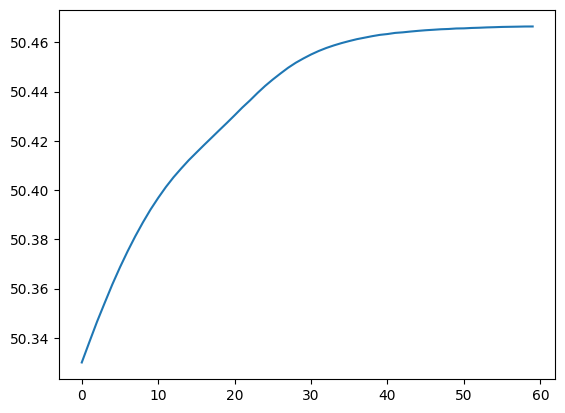

In [8]:
print(P)
plt.plot([k for k in range(60)], biomass_list)

In [4]:
print(params)

{'N': 10, 'L': 5, 'H': 1, 'nb_colonnes_default': 50, 'D': 1e-05, 'T': 300, 'CFL': 0.95, 'u': [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1], 'I_s': 1500, 'epsilon': 4.6, 'k_d': 0.000299, 'k_r': 0.00048, 'k_h': 0.000364, 'tau': 6.849, 'sigma_H': 0.0029, 'theta': 1.0556e-06, 'I_star': np.float64(166.94501039780602), 'mu_max': np.float64(3.315108749636504e-05)}


In [ ]:
params["u"] = [0.1]*10
params["N"] = 10
T = 300
P_, biomass_list_ = solve(X_ini_one_layer_torch(10, nb_colonnes_default), T, params)

0 50.35444641113281
1 50.36314392089844
2 50.371273040771484
3 50.378875732421875
4 50.38582992553711
5 50.39204406738281
6 50.397613525390625
7 50.40255355834961
8 50.407012939453125
9 50.41107177734375
10 50.414791107177734
11 50.418277740478516
12 50.42147445678711
13 50.424560546875
14 50.42747497558594
15 50.43046188354492
16 50.43336486816406
17 50.43623352050781
18 50.43920135498047
19 50.44224548339844
20 50.44534683227539
21 50.44850540161133
22 50.4516716003418
23 50.4547004699707
24 50.45765686035156
25 50.4604606628418
26 50.462913513183594
27 50.46510314941406
28 50.4669303894043
29 50.46855926513672
30 50.46994400024414
31 50.4710693359375
32 50.471961975097656
33 50.472694396972656
34 50.473358154296875
35 50.473876953125
36 50.47430419921875
37 50.47467041015625
38 50.47499465942383
39 50.47523498535156
40 50.47541809082031
41 50.47560119628906
42 50.47574234008789
43 50.47589111328125
44 50.47600555419922
45 50.47608947753906
46 50.4761848449707
47 50.47620391845703
48

tensor([[1.4456e-03, 1.7197e-03, 5.7424e-03, 4.6957e-04, 1.6288e-04, 8.5642e-05,
         6.4150e-04, 8.6562e-04, 2.5412e-02, 2.9409e-03],
        [8.9562e-04, 1.0148e-02, 1.3600e-03, 6.9982e-04, 1.0785e-03, 1.3373e-04,
         1.5376e-04, 2.8044e-03, 2.5194e-03, 2.3848e-03],
        [2.8590e-04, 2.4798e-03, 1.2982e-03, 5.1494e-04, 2.7010e-04, 2.0556e-04,
         3.4444e-03, 2.6894e-04, 2.3291e-02, 1.8091e-02],
        [1.3087e-03, 2.5852e-02, 1.6458e-02, 4.7746e-02, 5.8520e-03, 1.9064e-04,
         1.1030e-02, 4.5031e-03, 1.1860e-01, 1.6261e-01],
        [3.9982e-02, 6.1983e-02, 1.8771e-01, 6.8594e-01, 5.8067e-02, 2.1111e-03,
         2.7983e-01, 4.9754e-01, 4.3001e-01, 2.2449e-01],
        [9.4246e-01, 4.9230e-01, 5.6585e-02, 1.2618e-01, 9.1948e-01, 9.9609e-01,
         5.4018e-01, 2.5639e-01, 9.5704e-02, 3.5679e-01],
        [5.7892e-03, 1.9487e-01, 7.2620e-01, 1.2984e-01, 6.0737e-03, 9.5291e-04,
         1.4527e-01, 2.2152e-01, 1.4080e-01, 1.7911e-01],
        [7.1533e-03, 1.9219

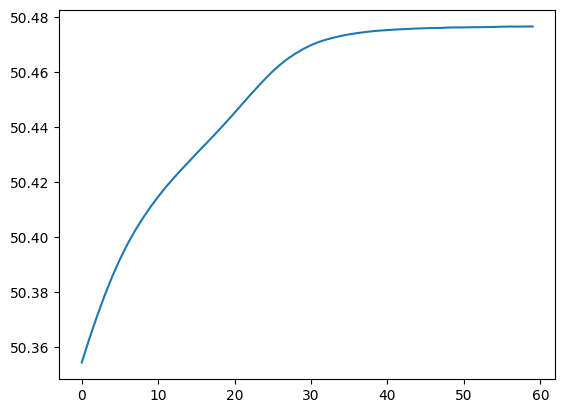

In [5]:
print(P_)
plt.plot([k for k in range(60)], biomass_list_)

In [3]:
params["u"] = [0.1]*20
params["N"] = 20
T = 300
P_20, biomass_list_20 = solve(X_ini_one_layer_torch(20, nb_colonnes_default), T, params)

0 50.36395263671875
1 50.3717041015625
2 50.37909698486328
3 50.38614273071289
4 50.392662048339844
5 50.39882278442383
6 50.40452575683594
7 50.409828186035156
8 50.41477584838867
9 50.419281005859375
10 50.423370361328125
11 50.427066802978516
12 50.430442810058594
13 50.43341827392578
14 50.43609619140625
15 50.43852996826172
16 50.44081115722656
17 50.44285583496094
18 50.444732666015625
19 50.446441650390625
20 50.44809341430664
21 50.44959259033203
22 50.45100021362305
23 50.45233154296875
24 50.4536247253418
25 50.454959869384766
26 50.45612335205078
27 50.45726013183594
28 50.45830154418945
29 50.45949935913086
30 50.46061325073242
31 50.46169662475586
32 50.46265411376953
33 50.4637336730957
34 50.46471405029297


tensor([[1.1427e-03, 1.9156e-03, 2.2509e-03, 2.1406e-03, 1.5372e-03, 1.2185e-03,
         8.4926e-04, 5.3591e-04, 4.8110e-04, 1.6607e-04, 3.0377e-04, 4.9521e-03,
         9.5927e-04, 4.0801e-04, 4.1795e-04, 2.9146e-03, 5.2093e-03, 6.8853e-03,
         1.7521e-02, 1.7326e-03],
        [4.9483e-03, 6.1887e-03, 4.8524e-03, 1.9977e-03, 9.4385e-03, 9.4021e-04,
         2.2423e-03, 4.9520e-04, 1.3265e-04, 2.4723e-04, 1.6795e-04, 3.6510e-04,
         5.6368e-04, 1.6309e-04, 4.6010e-04, 4.2356e-04, 2.5777e-03, 4.2709e-03,
         1.9225e-03, 1.0826e-03],
        [1.6059e-04, 2.3709e-03, 4.0244e-04, 8.8233e-04, 1.2488e-03, 7.5863e-04,
         4.6894e-04, 2.7740e-04, 8.7529e-05, 1.4258e-04, 7.8278e-04, 5.3651e-04,
         1.6121e-04, 6.1356e-04, 3.2966e-04, 7.6904e-04, 6.3528e-04, 5.9400e-03,
         9.4666e-04, 7.6786e-04],
        [3.3949e-04, 1.4379e-03, 5.2698e-04, 2.6029e-03, 2.9841e-03, 2.1810e-03,
         1.0685e-03, 4.6197e-04, 1.1677e-03, 1.4715e-04, 5.2394e-04, 2.4117e-04,
       

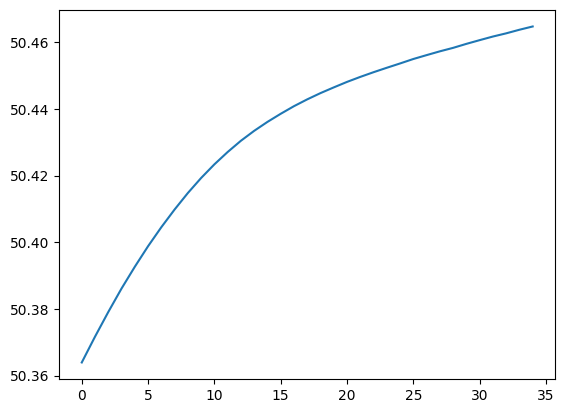

In [4]:
print(P_20)
plt.plot([k for k in range(35)], biomass_list_20)

In [ ]:
T = 300
P, biomass_list = solve(X_ini_one_layer_torch(5, nb_colonnes_default), T, params)


0 50.25628662109375
50 50.30965805053711
100 50.310272216796875


In [ ]:
print(P_)
print(biomass_list_)

tensor([[1.4041e-04, 2.8473e-03, 9.5556e-03, 2.0696e-04, 4.9693e-05, 1.8973e-04,
         5.6439e-04, 9.8612e-04, 1.1707e-03, 4.3672e-03],
        [6.5824e-05, 1.0563e-02, 1.1407e-03, 2.0222e-02, 3.3707e-04, 9.2370e-05,
         4.0554e-04, 7.1372e-03, 3.5983e-03, 6.2287e-03],
        [4.4433e-05, 9.4903e-03, 7.8348e-03, 3.4995e-03, 4.2907e-04, 5.5270e-05,
         2.5133e-04, 4.7080e-03, 4.2107e-03, 3.6368e-03],
        [7.0800e-04, 3.9395e-01, 3.7324e-01, 7.9597e-02, 1.2770e-04, 5.7395e-05,
         2.1784e-03, 1.1173e-01, 1.5130e-01, 8.2463e-02],
        [3.0304e-03, 2.8465e-01, 2.5055e-01, 7.1804e-02, 1.1742e-02, 4.4724e-04,
         5.0396e-01, 7.3372e-02, 1.9280e-01, 5.1491e-02],
        [9.9245e-01, 9.4936e-02, 7.5642e-02, 4.4277e-01, 9.8530e-01, 9.9889e-01,
         3.4541e-01, 5.1129e-01, 3.3142e-01, 5.9903e-01],
        [3.1089e-03, 8.6923e-02, 1.3955e-01, 3.7092e-01, 1.0411e-03, 7.4332e-05,
         1.4160e-01, 2.8273e-01, 2.6762e-01, 2.0348e-01],
        [1.0636e-04, 1.0268

: 

et pour une vitesse de 0.1 m/s ?

In [ ]:
params["u"] = [0.1]*5
params["N"] = 5
T = 300
P, biomass_list = solve(X_ini_one_layer_torch(10, nb_colonnes_default), T, params)


0 50.36369323730469
50 50.46880340576172


In [ ]:
print(P)
print(biomass_list)

tensor([[1.5897e-03, 5.6878e-03, 2.9148e-05, 7.6427e-04, 2.4059e-02],
        [5.9687e-04, 1.1356e-03, 1.0107e-05, 1.5381e-04, 1.2161e-01],
        [9.9155e-01, 6.5528e-01, 9.9501e-01, 9.8616e-01, 7.1232e-01],
        [6.1982e-03, 3.3559e-01, 4.9104e-03, 1.2670e-02, 1.3807e-01],
        [6.0579e-05, 2.3019e-03, 3.6566e-05, 2.4932e-04, 3.9409e-03]],
       grad_fn=<SoftmaxBackward0>)
[50.25628662109375, 50.260250091552734, 50.26421356201172, 50.268104553222656, 50.271881103515625, 50.27547836303711, 50.27886962890625, 50.28205108642578, 50.28504180908203, 50.28783416748047, 50.290443420410156, 50.292823791503906, 50.29498291015625, 50.296913146972656, 50.298614501953125, 50.300106048583984, 50.301387786865234, 50.30250549316406, 50.30344772338867, 50.304256439208984, 50.30495071411133, 50.30553436279297, 50.306034088134766, 50.306461334228516, 50.306827545166016, 50.30714797973633, 50.307411193847656, 50.307655334472656, 50.307861328125, 50.30804443359375, 50.308204650878906, 50.3083457

In [ ]:
X = X_ini_one_layer(5, nb_colonnes_default)
masse_totale, M, liste_biomasses= meilleure_matrice_de_permutation(X, T, params)
print(M)
print(masse_totale)

[[0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]]
50.31015568287362


In [ ]:
Q = P.detach()

print(Q)

print(fonction_objectif_torch(X_ini_one_layer_torch(5, nb_colonnes_default), T, P, params))
print(fonction_objectif(X_ini_one_layer(5, nb_colonnes_default), T, Q, params))

tensor([[1.5897e-03, 5.6878e-03, 2.9148e-05, 7.6427e-04, 2.4059e-02],
        [5.9687e-04, 1.1356e-03, 1.0107e-05, 1.5381e-04, 1.2161e-01],
        [9.9155e-01, 6.5528e-01, 9.9501e-01, 9.8616e-01, 7.1232e-01],
        [6.1982e-03, 3.3559e-01, 4.9104e-03, 1.2670e-02, 1.3807e-01],
        [6.0579e-05, 2.3019e-03, 3.6566e-05, 2.4932e-04, 3.9409e-03]])
tensor(50.3104, grad_fn=<SumBackward0>)
50.310465317081615


La matrice de permutation donne un meilleur rendement ... Et si on recommence le calcul, mais en partant d'une matrice très proche de cette matrice de permutation ?

In [3]:
P_new, biomass_list_new = solve(X_ini_one_layer_torch(5, nb_colonnes_default), T, params,
                                True, [[-1e16, -1e16, -1e16, -1e16, 0], 
                                      [-1e16, -1e16, -1e16, 0, -1e16],
                                      [0, -1e16, -1e16, -1e16, -1e16],
                                      [-1e16, -1e16, 0, -1e16, -1e16],
                                      [-1e16, 0, -1e16, -1e16, -1e16]])



RuntimeError: The size of tensor a (3) must match the size of tensor b (5) at non-singleton dimension 0

In [ ]:
print(P_new)
print(biomass_list_new)
Q_new = P_new.detach()
fonction_objectif(X_ini_one_layer_torch(5, nb_colonnes_default), T, Q_new, params)

tensor([[4.2511e-04, 1.1178e-02, 1.5017e-04, 9.4955e-04, 1.1094e-02],
        [2.4318e-04, 7.2756e-03, 1.0117e-04, 6.9247e-04, 7.1234e-03],
        [9.8735e-01, 5.4983e-01, 9.9605e-01, 9.4107e-01, 5.5555e-01],
        [1.1666e-02, 4.2256e-01, 3.5786e-03, 5.6507e-02, 4.1718e-01],
        [3.1183e-04, 9.1527e-03, 1.1774e-04, 7.7707e-04, 9.0435e-03]],
       grad_fn=<SoftmaxBackward0>)
[50.27333068847656, 50.27613830566406, 50.278987884521484, 50.281829833984375, 50.28462219238281, 50.28730010986328, 50.289833068847656, 50.29216384887695, 50.294281005859375, 50.29617691040039, 50.29784393310547, 50.29928207397461, 50.30052947998047, 50.30158615112305, 50.30248260498047, 50.303245544433594, 50.30388641357422, 50.30443572998047, 50.30490493774414, 50.30530548095703, 50.30565643310547, 50.30596160888672, 50.306236267089844, 50.30647277832031, 50.30669021606445, 50.30689239501953, 50.30707550048828, 50.3072509765625, 50.30740737915039, 50.30756378173828, 50.307708740234375, 50.3078498840332, 

np.float32(50.310562)

In [4]:

P, biomass_list = solve(X_ini_one_layer_torch(N, nb_colonnes_default), T, params)
print(f'P : {P}')
print(f'biomass list : {biomass_list}')
X = X_ini_one_layer(N, nb_colonnes_default)
masse_totale, M, liste_biomasses= meilleure_matrice_de_permutation(X, T, params)
print(f'best permutation matrix : {M}')
print(f'masse totale : {masse_totale}')

Failed to read module file 'c:\Users\olitrico\Desktop\stage_inria_ordi_pro\pytorch_optim.py' for module 'pytorch_optim': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\olitrico\AppData\Roaming\Python\Python312\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 556, in maybe_reload_module
    new_source_code = f.read()
                      ^^^^^^^^
  File "c:\Users\olitrico\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 8059: character maps to <undefined>
c:\Users\olitrico\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\autograd\graph.py:865: UserWarning: Error detected in MvBackward0. Traceback of forward call that caused the error:
  File "<frozen runpy>", line 198, in _run_module_as

RuntimeError: one of the variables needed for gradient computation has been modified by an inplace operation: [torch.FloatTensor [3]], which is output 0 of AsStridedBackward0, is at version 1; expected version 0 instead. Hint: the backtrace further above shows the operation that failed to compute its gradient. The variable in question was changed in there or anywhere later. Good luck!

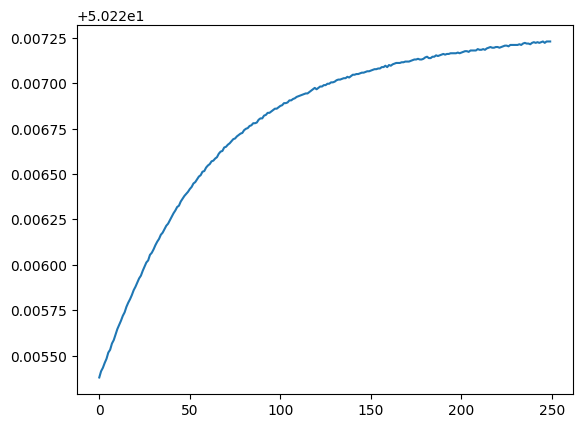

In [ ]:
plt.plot([k for k in range(250)], biomass_list)

In [ ]:
print(P)

tensor([[0.0186, 0.1844, 0.0070],
        [0.0078, 0.0743, 0.0179],
        [0.9736, 0.7413, 0.9751]], grad_fn=<SoftmaxBackward0>)


In [ ]:
lrs, losses = lr_finder(X_ini_one_layer_torch(N, nb_colonnes_default), T, params)

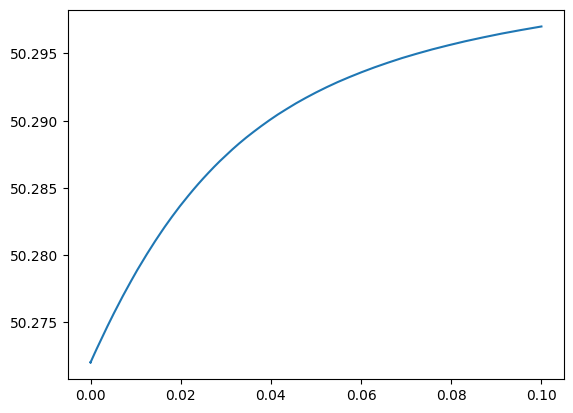

In [ ]:
plt.plot(lrs, losses)

Methode de Newton

In [ ]:
N_lignes = params["N"]
Q = torch.nn.Parameter(torch.randn(N_lignes, N_lignes))
def J(Q):
    P = torch.softmax(Q, dim=0)
    return(fonction_objectif_torch(X_ini_one_layer_torch(N_lignes, nb_colonnes_default), T, P, params))

Q_sol, masse_tot_max = Newton(J, Q)
print(torch.softmax(Q_sol, dim=0))
print(f'masse finale : {masse_tot_max}')